In [81]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
!ls /content/drive/MyDrive/Sentiment_Analysis

training.1600000.processed.noemoticon.csv


In [83]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [84]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [85]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Data Processing

In [86]:
twitter_data = pd.read_csv('/content/drive/MyDrive/Sentiment_Analysis/training.1600000.processed.noemoticon.csv', encoding='ISO-8859-1')

In [87]:
twitter_data.shape

(1599999, 6)

In [88]:
twitter_data.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [89]:
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv('/content/drive/MyDrive/Sentiment_Analysis/training.1600000.processed.noemoticon.csv',names = column_names,  encoding='ISO-8859-1')

In [90]:
twitter_data.shape

(1600000, 6)

In [91]:
#counting missing values in the dataset
twitter_data.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0


In [92]:
#checking the distribution of target columns
twitter_data['target'].value_counts()

,count
target,
0,800000
4,800000


Converting the target "4" to "1"

In [93]:
twitter_data.replace({'target':{4:1}}, inplace = True)

In [94]:
#checking the distribution of target columns
twitter_data['target'].value_counts()

,count
target,
0,800000
1,800000


0 -- means Negative
1 -- Positive


**Stemming**

In [95]:
port_stem = PorterStemmer()
def  stemming(content):
  stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
  stemmed_content = stemmed_content.lower()
  stemmed_content = stemmed_content.split()
  stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
  stmmed_content = ' '.join(stemmed_content)

  return stemmed_content

In [96]:
twitter_data ['stemmed_content'] =twitter_data['text'].apply(stemming)

In [97]:
twitter_data.head()

,target,id,date,flag,user,text,stemmed_content
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...","[switchfoot, http, twitpic, com, zl, awww, bum..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,"[upset, updat, facebook, text, might, cri, res..."
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,"[kenichan, dive, mani, time, ball, manag, save..."
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,"[whole, bodi, feel, itchi, like, fire]"
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....","[nationwideclass, behav, mad, see]"


In [98]:
#separating the data and label
X = twitter_data['stemmed_content'].values
Y = twitter_data ['target'].values

In [99]:
#splitting train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify= Y, random_state =2)

In [100]:
# Vectorization
vectorizer = TfidfVectorizer(max_features=5000)

# Join the lists of stemmed words into single strings
X_train_processed = [' '.join(doc) for doc in X_train]
X_test_processed = [' '.join(doc) for doc in X_test]

X_train = vectorizer.fit_transform(X_train_processed)
X_test  = vectorizer.transform(X_test_processed)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

# Evaluation
train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

print("Train Accuracy:", accuracy_score(Y_train, train_pred))
print("Test Accuracy :", accuracy_score(Y_test, test_pred))

Train Accuracy: 0.76972265625
Test Accuracy : 0.767578125


In [101]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, model.predict(X_test)))


              precision    recall  f1-score   support

           0       0.78      0.75      0.76    160000
           1       0.76      0.79      0.77    160000

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000



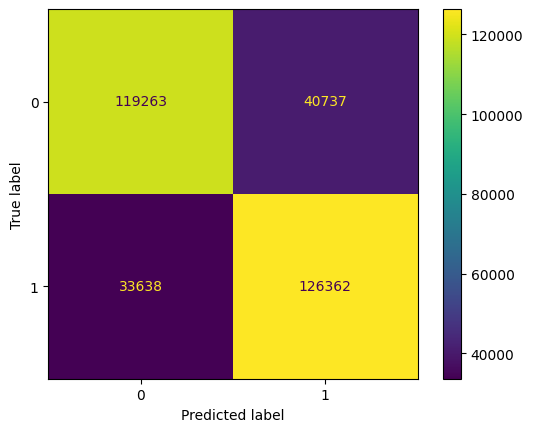

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(Y_test, model.predict(X_test))


In [103]:
import joblib
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']